# Customer Behavior & Cohort Retention

Acquiring a customer is expensive. Keeping them is where the profit is. This 
notebook looks at how customers behave after their first purchase and do they 
come back? How quickly? And what does the retention curve actually look like?


In [11]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

con = duckdb.connect()

DATA_PATH = r"C:\Users\UCWAcc\projects\ecommerce-analytics\data"

con.execute(f"""
    CREATE TABLE customers AS SELECT * FROM read_csv_auto('{DATA_PATH}/olist_customers_dataset.csv');
    CREATE TABLE orders AS SELECT * FROM read_csv_auto('{DATA_PATH}/olist_orders_dataset.csv');
    CREATE TABLE order_items AS SELECT * FROM read_csv_auto('{DATA_PATH}/olist_order_items_dataset.csv');
    CREATE TABLE products AS SELECT * FROM read_csv_auto('{DATA_PATH}/olist_products_dataset.csv');
    CREATE TABLE reviews AS SELECT * FROM read_csv_auto('{DATA_PATH}/olist_order_reviews_dataset.csv');
    CREATE TABLE geolocation AS SELECT * FROM read_csv_auto('{DATA_PATH}/olist_geolocation_dataset.csv');
    CREATE TABLE category_translation AS SELECT * FROM read_csv_auto('{DATA_PATH}/product_category_name_translation.csv');
""")

def sql(query):
    return con.execute(query).fetchdf()

## How many customers are repeat buyers?



In [13]:
repeat = sql("""
    WITH customer_orders AS (
        SELECT c.customer_unique_id,
               COUNT(DISTINCT o.order_id) AS order_count
        FROM customers c
        JOIN orders o ON c.customer_id = o.customer_id
        WHERE o.order_status = 'delivered'
        GROUP BY c.customer_unique_id
    )
    SELECT 
        COUNT(*) AS total_customers,
        SUM(CASE WHEN order_count = 1 THEN 1 ELSE 0 END) AS one_time_buyers,
        SUM(CASE WHEN order_count > 1 THEN 1 ELSE 0 END) AS repeat_buyers,
        ROUND(SUM(CASE WHEN order_count > 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS repeat_rate_pct
    FROM customer_orders
""")
repeat

,total_customers,one_time_buyers,repeat_buyers,repeat_rate_pct
0,93358,90557.0,2801.0,3.0


That 3% repeat rate is remarkably low, even for a marketplace. It means almost every sale requires finding and converting a brand-new customer, which is the most expensive way to grow.


## Customer distribution by order count

Let's see the full picture . how many customers placed 1 order, 2 orders, 
3 orders, etc.

In [16]:
order_dist = sql("""
    WITH customer_orders AS (
        SELECT c.customer_unique_id,
               COUNT(DISTINCT o.order_id) AS order_count
        FROM customers c
        JOIN orders o ON c.customer_id = o.customer_id
        WHERE o.order_status = 'delivered'
        GROUP BY c.customer_unique_id
    )
    SELECT order_count,
           COUNT(*) AS num_customers,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) AS pct
    FROM customer_orders
    GROUP BY order_count
    ORDER BY order_count
""")
order_dist

,order_count,num_customers,pct
0,1,90557,97.0
1,2,2573,2.8
2,3,181,0.2
3,4,28,0.0
4,5,9,0.0
5,6,5,0.0
6,7,3,0.0
7,9,1,0.0
8,15,1,0.0


## Monthly cohort retention

This is the core analysis. We group customers by the month they made their 
first purchase (their "cohort"), then track how many of them come back in 
subsequent months.

The SQL here is the most complex in this project, multiple CTEs chained 
together. Breaking it down:
1. Find each customer's first purchase month
2. Find all their order months  
3. Calculate how many months after their first purchase each order was
4. Count unique customers at each offset per cohort

In [18]:
cohort = sql("""
    WITH first_purchase AS (
        SELECT c.customer_unique_id,
               DATE_TRUNC('month', MIN(o.order_purchase_timestamp)) AS cohort_month
        FROM customers c
        JOIN orders o ON c.customer_id = o.customer_id
        WHERE o.order_status = 'delivered'
        GROUP BY c.customer_unique_id
    ),
    all_orders AS (
        SELECT c.customer_unique_id,
               DATE_TRUNC('month', o.order_purchase_timestamp) AS order_month
        FROM customers c
        JOIN orders o ON c.customer_id = o.customer_id
        WHERE o.order_status = 'delivered'
    ),
    with_offset AS (
        SELECT fp.cohort_month,
               ao.customer_unique_id,
               DATEDIFF('month', fp.cohort_month, ao.order_month) AS months_since_first
        FROM first_purchase fp
        JOIN all_orders ao ON fp.customer_unique_id = ao.customer_unique_id
    )
    SELECT cohort_month,
           months_since_first,
           COUNT(DISTINCT customer_unique_id) AS customers
    FROM with_offset
    WHERE months_since_first <= 12
    GROUP BY cohort_month, months_since_first
    ORDER BY cohort_month, months_since_first
""")
cohort.head(20)

,cohort_month,months_since_first,customers
0,2016-09-01,0,1
1,2016-10-01,0,262
2,2016-10-01,6,1
3,2016-10-01,9,1
4,2016-10-01,11,1
5,2016-12-01,0,1
6,2016-12-01,1,1
7,2017-01-01,0,717
8,2017-01-01,1,2
9,2017-01-01,2,2


### Turning it into a retention heatmap

The raw numbers above are hard to read. A heatmap makes the pattern 
immediately obvious - dark cells mean high retention, light cells mean 
people dropped off.

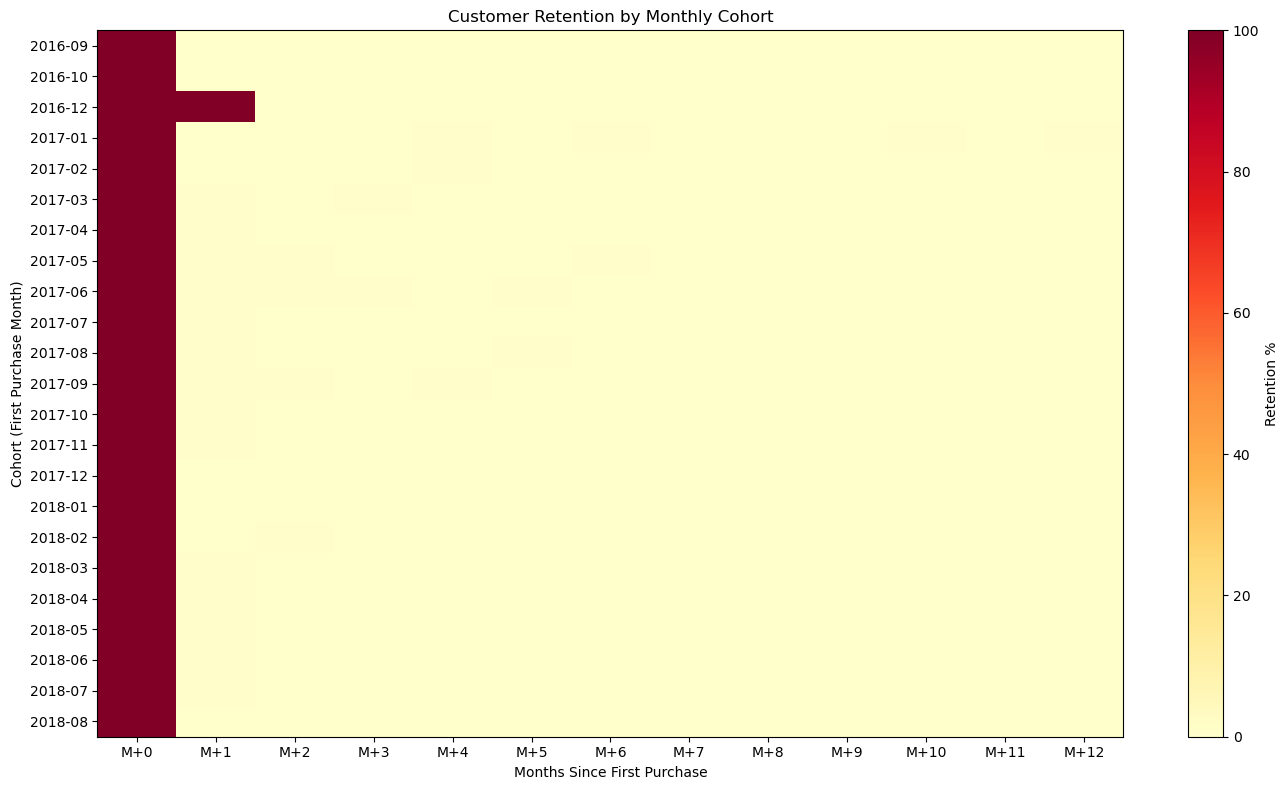

In [20]:
# Pivot into a matrix: cohort_month × months_since_first
pivot = cohort.pivot(index='cohort_month', columns='months_since_first', values='customers').fillna(0)

# Convert to retention percentages (each row relative to month 0)
retention = pivot.div(pivot[0], axis=0) * 100

# Only show cohorts with enough data (at least 3 months of history)
retention = retention[retention.columns[:13]]

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(retention.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)

ax.set_xticks(range(retention.shape[1]))
ax.set_xticklabels([f'M+{i}' for i in range(retention.shape[1])])
ax.set_yticks(range(retention.shape[0]))
ax.set_yticklabels([str(d)[:7] for d in retention.index])
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Cohort (First Purchase Month)')
ax.set_title('Customer Retention by Monthly Cohort')

plt.colorbar(im, ax=ax, label='Retention %')
plt.tight_layout()
plt.show()

## Time between first and second purchase

For the customers who DO come back, how long does it take? This helps 
answer "when should we send a re-engagement email?"

In [22]:
time_to_second = sql("""
    WITH ordered_purchases AS (
        SELECT c.customer_unique_id,
               o.order_purchase_timestamp,
               ROW_NUMBER() OVER (
                   PARTITION BY c.customer_unique_id 
                   ORDER BY o.order_purchase_timestamp
               ) AS purchase_num
        FROM customers c
        JOIN orders o ON c.customer_id = o.customer_id
        WHERE o.order_status = 'delivered'
    ),
    first_and_second AS (
        SELECT customer_unique_id,
               MAX(CASE WHEN purchase_num = 1 THEN order_purchase_timestamp END) AS first_order,
               MAX(CASE WHEN purchase_num = 2 THEN order_purchase_timestamp END) AS second_order
        FROM ordered_purchases
        WHERE purchase_num <= 2
        GROUP BY customer_unique_id
        HAVING second_order IS NOT NULL
    )
    SELECT ROUND(AVG(DATEDIFF('day', first_order, second_order)), 0) AS avg_days_to_second,
           ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY DATEDIFF('day', first_order, second_order)), 0) AS median_days,
           MIN(DATEDIFF('day', first_order, second_order)) AS min_days,
           MAX(DATEDIFF('day', first_order, second_order)) AS max_days
    FROM first_and_second
""")
time_to_second

,avg_days_to_second,median_days,min_days,max_days
0,81.0,29.0,0,609


## Revenue contribution: new vs returning customers

How much revenue comes from first-time buyers vs repeat customers? 
This answers the question of whether the business is running on 
acquisition or loyalty.

In [24]:
new_vs_returning = sql("""
    WITH customer_first AS (
        SELECT c.customer_unique_id,
               MIN(o.order_purchase_timestamp) AS first_order_date
        FROM customers c
        JOIN orders o ON c.customer_id = o.customer_id
        WHERE o.order_status = 'delivered'
        GROUP BY c.customer_unique_id
    ),
    labeled_orders AS (
        SELECT o.order_id,
               DATE_TRUNC('month', o.order_purchase_timestamp) AS order_month,
               CASE 
                   WHEN o.order_purchase_timestamp = cf.first_order_date THEN 'New'
                   ELSE 'Returning'
               END AS customer_type
        FROM orders o
        JOIN customers c ON o.customer_id = c.customer_id
        JOIN customer_first cf ON c.customer_unique_id = cf.customer_unique_id
        WHERE o.order_status = 'delivered'
    )
    SELECT lo.customer_type,
           COUNT(DISTINCT lo.order_id) AS orders,
           ROUND(SUM(oi.price), 2) AS revenue,
           ROUND(AVG(oi.price), 2) AS avg_item_price
    FROM labeled_orders lo
    JOIN order_items oi ON lo.order_id = oi.order_id
    GROUP BY lo.customer_type
    ORDER BY revenue DESC
""")
new_vs_returning

,customer_type,orders,revenue,avg_item_price
0,New,93613,12863149.53,120.56
1,Returning,2865,358348.58,102.44


## Average order value: first purchase vs subsequent

Do returning customers spend more per order? If yes, that strengthens the 
case for investing in retention programs.

In [26]:
aov_by_purchase = sql("""
    WITH numbered AS (
        SELECT c.customer_unique_id,
               o.order_id,
               ROW_NUMBER() OVER (
                   PARTITION BY c.customer_unique_id 
                   ORDER BY o.order_purchase_timestamp
               ) AS purchase_num
        FROM customers c
        JOIN orders o ON c.customer_id = o.customer_id
        WHERE o.order_status = 'delivered'
    )
    SELECT CASE 
               WHEN n.purchase_num = 1 THEN '1st purchase'
               WHEN n.purchase_num = 2 THEN '2nd purchase'
               WHEN n.purchase_num = 3 THEN '3rd purchase'
               ELSE '4th+ purchase'
           END AS purchase_number,
           COUNT(DISTINCT n.order_id) AS orders,
           ROUND(AVG(oi.price), 2) AS avg_item_price,
           ROUND(SUM(oi.price) / COUNT(DISTINCT n.order_id), 2) AS avg_order_value
    FROM numbered n
    JOIN order_items oi ON n.order_id = oi.order_id
    GROUP BY CASE 
               WHEN n.purchase_num = 1 THEN '1st purchase'
               WHEN n.purchase_num = 2 THEN '2nd purchase'
               WHEN n.purchase_num = 3 THEN '3rd purchase'
               ELSE '4th+ purchase'
           END
    ORDER BY purchase_number
""")
aov_by_purchase

,purchase_number,orders,avg_item_price,avg_order_value
0,1st purchase,93358,120.63,137.48
1,2nd purchase,2801,102.99,124.06
2,3rd purchase,228,91.72,121.48
3,4th+ purchase,91,92.03,122.36


## Takeaways

**97% of customers never come back.** Only 3% of customers place a second order. This is the single most important number in the dataset. The business is almost entirely acquisition-driven , $12.9 million dollars  from new customers vs 358k dollars from returning ones. Every month's revenue depends on finding fresh buyers, which is expensive and unsustainable at scale.

**The few who return, return fast.** Median time to second purchase is 29 days. That's a surprisingly tight window and a clear signal: if a re-engagement campaign (email, push notification, discount code) is going to work, it needs to fire within the first month after purchase. Waiting 60-90 days means you've already lost most of the recoverable customers.

**Marketplace dynamics explain the low repeat rate.** Customers on a marketplace like Olist often don't build loyalty to the platform — they search for a product, buy it, and may not return unless they need something else. This is structurally different from a single-brand store. Improving repeat rate even slightly (say, from 3% to 6%) would meaningfully reduce acquisition dependency, but it requires deliberate platform-level retention tactics: personalized recommendations, post-purchase follow-ups, loyalty programs.

**Revenue contribution confirms the acquisition trap.** Returning customers generate only 2.7% of total revenue. The business is essentially a funnel with no retention loop. This is workable at high growth (which the revenue trend shows), but becomes a serious vulnerability if acquisition costs rise or growth slows.
